# A Deep Dive into Bayesian Model Comparison with BayesFlow

_Author: Jerry M. Huang_

In this notebook, we take a deep dive into Bayesian model comparison by demonstrating the `ModelComparisonWorkflow` in BayesFlow. We will demonstrate two common scenarios for model comparison based on two families of scoring rules that BayesFlow has to offer:

* **PMP (Posterior Model Probability) rules** — the network outputs softmax probabilities over all models.
* **Bayes factor rules** — the network outputs $M−1$ log Bayes factors $log K_{k,ref}$ relative to a reference model.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

import bayesflow as bf
from bayesflow.workflows import ModelComparisonWorkflow
from bayesflow.scoring_rules import (
    CrossEntropyScore,
    SquaredScore,
    PolynomialScore,
    ExponentialScore,
    LogisticScore,
    AlphaExponentialScore,
    LPOPExponentialScore,
    AlphaLogExponentialScore,
)
import bayesflow.diagnostics.plots as bf_plots

## Two families of scoring rules

BayesFlow supports two families of scoring rules for model comparison:

**PMP (Posterior Model Probability) rules** — the network outputs softmax probabilities over all models.  Diagnostics: confusion matrix and calibration curves.

| Class | Loss |
|-------|------|
| `CrossEntropyScore` | Categorical cross-entropy (default) |
| `SquaredScore` | Brier score (squared error on softmax probabilities) |
| `PolynomialScore` | Polynomial scoring rule; `alpha=2` recovers the Brier score |

**Bayes factor rules** — the network outputs M−1 log Bayes factors log K_{k,ref} relative to a reference model.  Diagnostics: blind coverage test and Bayes factor recovery.

| Class | Notes |
|-------|-------|
| `ExponentialScore` | Baseline Bayes factor rule |
| `LogisticScore` | Softplus-based; numerically more stable |
| `AlphaExponentialScore` | Exponential × polynomial envelope (default α=0.5) |
| `LPOPExponentialScore` | **Recommended** — l-POP transform before exp |
| `AlphaLogExponentialScore` | Log-sum-exp variant (default α=1.0) |

## Simulators

To demonstrate with an application scenario, we discriminate between four models within the generalized autoregressive conditional heteroscedasticity (GARCH) model family, commonly used in computational finance.

| Model | Key feature |
|-------|-------------|
| ARCH(1) | Short-memory ARCH: volatility shocks decay in one step |
| GARCH(1,1) | Persistent volatility clustering, Gaussian innovations |
| GJR-GARCH(1,1) | Leverage effect: negative shocks inflate variance more |
| GARCH-t | GARCH(1,1) with Student-t innovations; heavier tails |

Rather than hand-crafting summary statistics, we feed the raw return series directly into a `TimeSeriesTransformer` summary network and let the network learn what to look at — a more principled and typically more powerful approach.

Each model is defined by a **prior function** that draws parameters, and all four share a single **likelihood function** that runs the GARCH recursion.  `bf.make_simulator` chains them so that the prior's output dict is forwarded automatically as keyword arguments to the likelihood.

The unified likelihood covers all four models via its optional parameters:

| Model | `beta` | `gamma` | `nu` |
|-------|--------|---------|------|
| ARCH(1) | 0 (default) | 0 (default) | None (default) |
| GARCH(1,1) | sampled | 0 (default) | None (default) |
| GJR-GARCH(1,1) | sampled | sampled | None (default) |
| GARCH-t | sampled | 0 (default) | sampled |

The prior functions are also reused later for importance-sampling log marginal likelihood estimates, so each model's prior is defined exactly once.

In [13]:
def arch_prior():
    return dict(
        omega=np.random.uniform(5e-5, 2e-4),
        alpha=np.random.uniform(0.10, 0.40),   # α < 1 ensures stationarity
        beta =0.0,
        gamma=0.0,
        nu   =np.inf,
        mu   =np.random.uniform(-5e-4, 5e-4),
    )


def garch_prior():
    return dict(
        omega=np.random.uniform(1e-6, 5e-5),
        alpha=np.random.uniform(0.05, 0.15),
        beta =np.random.uniform(0.75, 0.84),   # α + β ≤ 0.99
        gamma=0.0,
        nu   =np.inf,
        mu   =np.random.uniform(-5e-4, 5e-4),
    )


def gjr_prior():
    return dict(
        omega=np.random.uniform(1e-6, 5e-5),
        alpha=np.random.uniform(0.02, 0.08),
        gamma=np.random.uniform(0.05, 0.12),   # α + γ/2 + β ≤ 0.99
        beta =np.random.uniform(0.75, 0.85),
        nu   =np.inf,
        mu   =np.random.uniform(-5e-4, 5e-4),
    )


def garcht_prior():
    return dict(
        omega=np.random.uniform(1e-6, 5e-5),
        alpha=np.random.uniform(0.05, 0.15),
        beta =np.random.uniform(0.75, 0.84),   # α + β ≤ 0.99
        gamma=0.0,
        nu   =np.random.uniform(4.0, 10.0),    # restricted range ensures meaningfully heavy tails
        mu   =np.random.uniform(-5e-4, 5e-4),
    )

In [14]:
def garch_likelihood(omega, alpha, mu, beta=0.0, gamma=0.0, nu=None, T=500, burn_in=50, **kwargs):
    """Shared GARCH likelihood for all four models.

    beta=0, gamma=0, nu=None/inf  →  ARCH(1)
    gamma=0, nu=None/inf          →  GARCH(1,1)
    nu=None/inf                   →  GJR-GARCH(1,1)
    nu provided and finite        →  GARCH-t (Student-t innovations scaled to unit variance)
    """
    T_total = T + burn_in
    returns = np.empty(T_total)
    eps    = 0.0
    sigma2 = omega / max(1.0 - alpha - gamma / 2.0 - beta, 1e-6)

    use_gaussian = nu is None or np.isinf(nu)

    for t in range(T_total):
        I_neg  = float(eps < 0)
        sigma2 = omega + (alpha + gamma * I_neg) * eps**2 + beta * sigma2
        sigma2 = np.clip(sigma2, 1e-10, 1.0)   # cap prevents volatility explosion
        if use_gaussian:
            z = np.random.randn()
        else:
            z = np.random.standard_t(nu) * np.sqrt((nu - 2) / nu)
        eps    = np.sqrt(sigma2) * z
        returns[t] = mu + eps

    # Clip to ±1.0 (±100% daily return): bounds the network input and IS et terms,
    # preventing NaN in LayerNorm and IS sigma2 divergence on extreme t-draws.
    out = np.clip(returns[burn_in:], -1.0, 1.0)
    return {"returns": out[:, np.newaxis].astype(np.float32)}

In [15]:
simulators = [
    bf.make_simulator([arch_prior,    garch_likelihood]),
    bf.make_simulator([garch_prior,  garch_likelihood]),
    bf.make_simulator([gjr_prior, garch_likelihood]),
    bf.make_simulator([garcht_prior,   garch_likelihood]),
]

T           = 500
MODEL_NAMES = ["ARCH", "GARCH", "GJR", "GARCH-t"]

### Prior predictive check

A single draw from each simulator illustrates the qualitative differences the network will learn to detect.

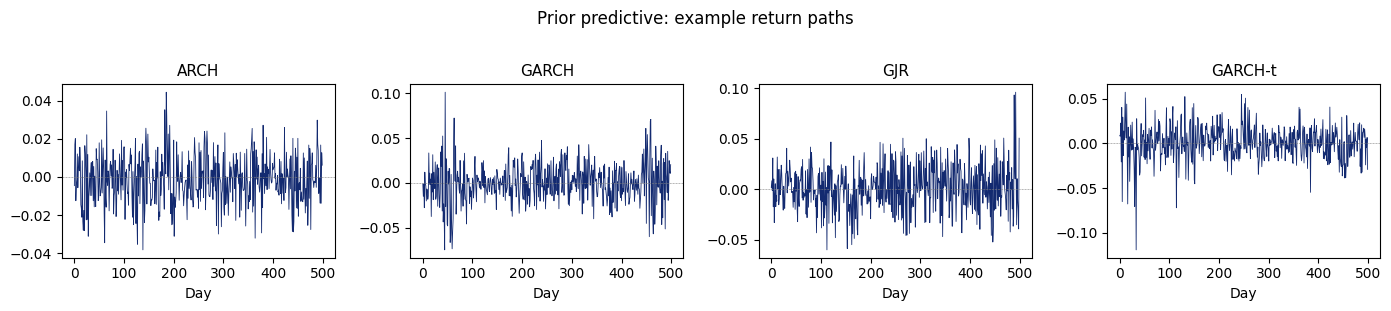

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=False)
for ax, sim, name in zip(axes, simulators, MODEL_NAMES):
    path = sim.sample((1,))["returns"][0, :, 0]
    ax.plot(path, linewidth=0.6, color="#132a70")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Day")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle="--")
plt.suptitle("Prior predictive: example return paths", y=1.02)
plt.tight_layout()
plt.show()

---

## Part 1 — PMP Scoring Rules

PMP scoring rules train the network to output softmax probabilities over all models. The three available rules differ only in their loss function; they share the same network architecture and produce identical output shapes.

We train with the default `CrossEntropyScore`.  To switch to another PMP rule, pass `scoring_rule=SquaredScore()` or `scoring_rule=PolynomialScore(alpha=3.0)` — everything else stays the same.

In [17]:
pmp_workflow = ModelComparisonWorkflow(
    simulator=simulators,
    summary_variables=["returns"],
    summary_network="time_series_transformer",
    model_names=MODEL_NAMES,
    scoring_rule=CrossEntropyScore(),  # default; may be omitted
)

# Alternative PMP scoring rules (same API, just swap scoring_rule=):
#
# pmp_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=SquaredScore()
# )
#
# pmp_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=PolynomialScore(alpha=2.0)  # alpha=2 recovers Brier score
# )

In [18]:
history_pmp = pmp_workflow.fit_online(
    epochs=50,
    num_batches_per_epoch=150,
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - loss: 1.3692 - scoring_rule/inference_scoring_rule: 1.3692
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 1.3393 - scoring_rule/inference_scoring_rule: 1.3393
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 1.3393 - scoring_rule/inference_scoring_rule: 1.3393
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 1.3123 - scoring_rule/inference_scoring_rule: 1.3123
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - loss: 1.2088 - scoring_rule/inference_scoring_rule: 1.2088
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - loss: 1.3197 - scoring_rule/inference_scoring_rule: 1.3197
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - loss: 1.2324 - scoring_rule/inference_scoring_rule: 1.2324
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - loss: 1.0176 - scoring_rule/inference_scoring_rule: 1.0176
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - loss: 1.0057 - scoring_r

INFO:bayesflow:Training completed in 10.74 minutes.


### Diagnostics — PMP rules

`plot_default_diagnostics` detects the active scoring rule and automatically produces the appropriate plots.  For PMP rules these are:

- **Loss curve** — training and validation cross-entropy over epochs.
- **Confusion matrix** — rows = true model, columns = predicted model (argmax of PMPs).
- **Calibration curves** — per-model ECE-annotated reliability diagrams.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Prediction completed in 0.15 seconds.


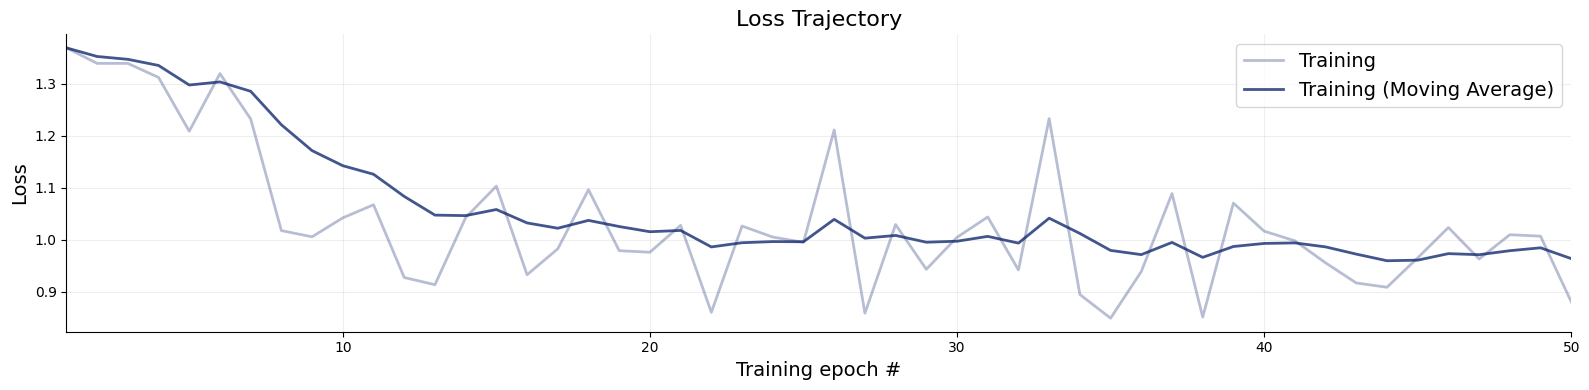

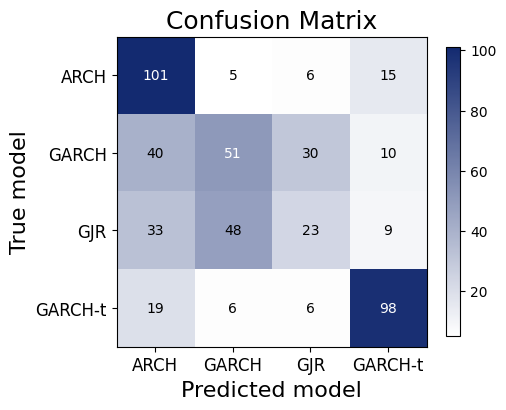

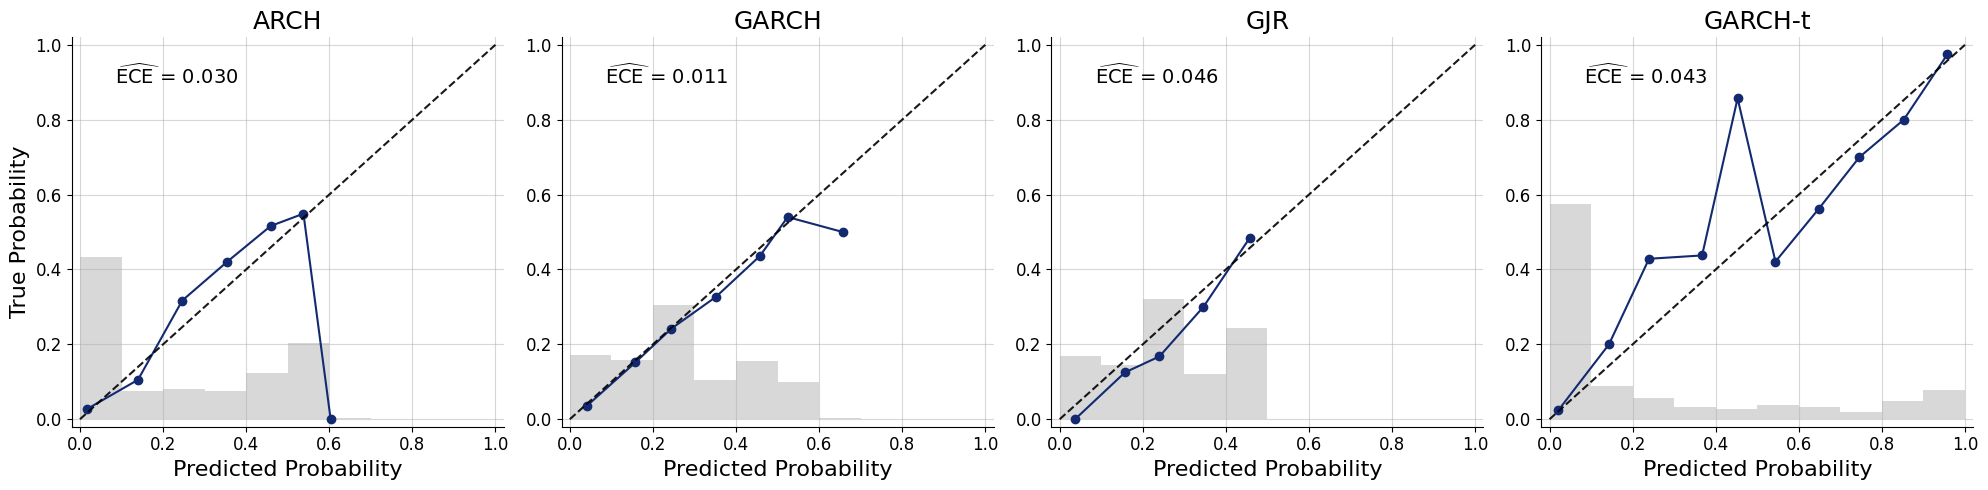

In [19]:
figs_pmp = pmp_workflow.plot_default_diagnostics(test_data=500)

## Part 2 — Bayes Factor Scoring Rules

Bayes factor scoring rules train the network to output **log Bayes factors** log K_{k,0} for each competing model k relative to the reference model (model 0 by default). The output shape is `(num_datasets, num_models - 1)`.

All five rules share the same network structure and diagnostics; they differ in how they penalize incorrect rankings:

| Rule | Key property |
|------|--------------|
| `ExponentialScore` | Baseline; may be unstable when log BF magnitudes are large |
| `LogisticScore` | Softplus penalty; numerically more stable than exponential |
| `AlphaExponentialScore(alpha)` | Exponential × polynomial envelope; α=0.5 default |
| `LPOPExponentialScore(alpha)` | **Recommended** — l-POP transform regularises large outputs |
| `AlphaLogExponentialScore(alpha)` | Log-sum-exp variant; interpolates between max and sum |

We train with `LPOPExponentialScore`, which applies the leaky parity-odd power transform $J_\alpha(x) = x + x|x|^{(\alpha−1)}$ before the exponential, giving well-calibrated estimates even when true log Bayes factors are large.

In [20]:
bayes_factor_workflow = ModelComparisonWorkflow(
    simulator=simulators,
    summary_variables=["returns"],
    summary_network="time_series_transformer",
    model_names=MODEL_NAMES,
    scoring_rule=LogisticScore(),
)

# Other Bayes factor scoring rules (same API, just swap scoring_rule=):
#
# bayes_factor_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=ExponentialScore()
# )
#
# bayes_factor_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=AlphaExponentialScore(alpha=0.5)
# )
#
# bayes_factor_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=LPOPExponentialScore(alpha=0.5)
# )
#
# bayes_factor_workflow = ModelComparisonWorkflow(
#     ..., scoring_rule=AlphaLogExponentialScore(alpha=1.0)
# )

In [21]:
history_bayes_factor = bayes_factor_workflow.fit_online(
    epochs=50,
    num_batches_per_epoch=150,
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - loss: 2.3516 - scoring_rule/inference_scoring_rule: 2.3516
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - loss: 2.1355 - scoring_rule/inference_scoring_rule: 2.1355
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - loss: 2.1795 - scoring_rule/inference_scoring_rule: 2.1795
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - loss: 2.0875 - scoring_rule/inference_scoring_rule: 2.0875
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - loss: 2.3812 - scoring_rule/inference_scoring_rule: 2.3812
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - loss: 2.1287 - scoring_rule/inference_scoring_rule: 2.1287
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - loss: 2.2224 - scoring_rule/inference_scoring_rule: 2.2224
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - loss: 2.1471 - scoring_rule/inference_scoring_rule: 2.1471
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - loss: 2.1263 - scoring_r

INFO:bayesflow:Training completed in 10.76 minutes.


### Diagnostics — Bayes factor rules

`plot_default_diagnostics` detects the Bayes factor rule and automatically switches to
the **blind coverage test** (Jeffrey & Wandelt 2024) instead of the PMP diagnostics.

For PMP rules these are:

- **Loss curve** — training and validation loss over epochs.
- **Blind coverage** — one panel per competing model.  For each marginal quantile
  level α the plot shows what fraction of each model group's predicted log K falls at
  or below the α-quantile of the *full* (model-label-free) predicted log K
  distribution.  A well-calibrated estimator pushes the reference-model curve *above*
  the diagonal and the competing-model curve *below* it.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Prediction completed in 0.71 seconds.


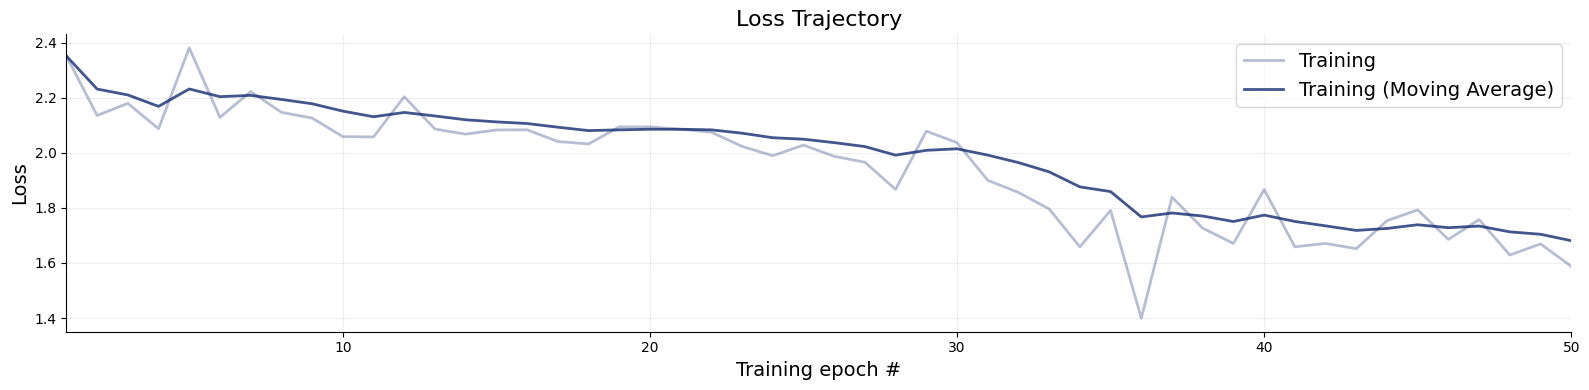

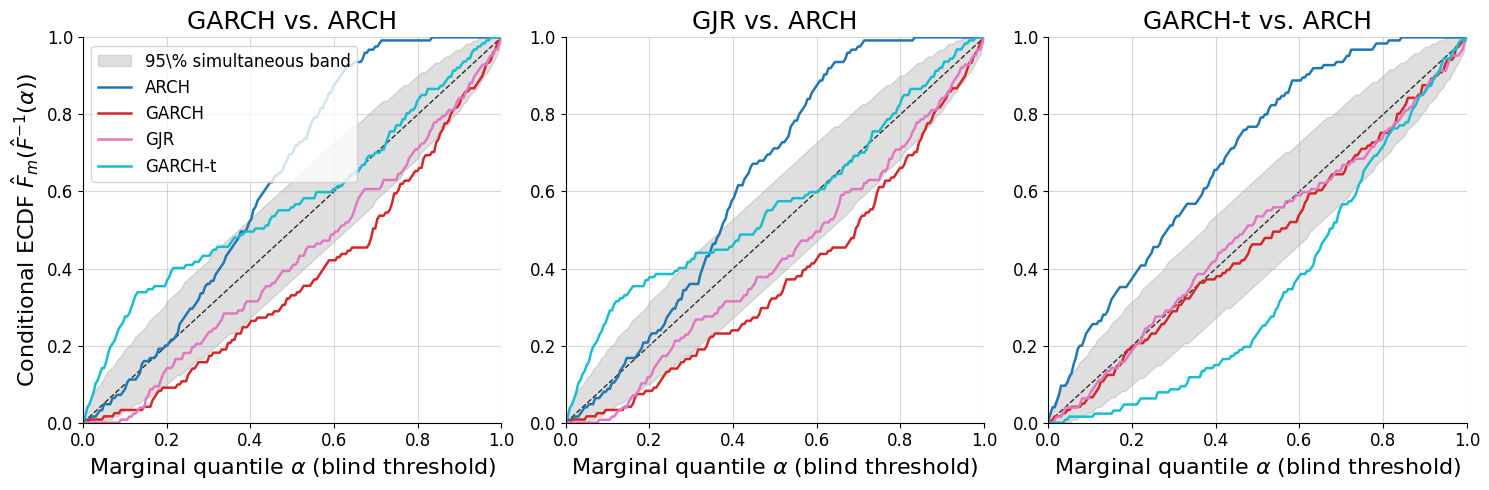

In [22]:
figures = bayes_factor_workflow.plot_default_diagnostics(test_data=500)

### Bayes factor recovery via importance sampling

`bayes_factor_recovery` requires ground-truth log Bayes factors.  GARCH models have no analytic marginal likelihood, but the likelihood *is* evaluable in closed form given parameters and data — which is all importance sampling needs.

Drawing S parameter vectors from the prior and averaging the resulting likelihoods gives a consistent estimator of the log marginal likelihood for each model:

$$\log \hat{p}(\mathbf{y} \mid \mathcal{M}_k) = \log\!\sum_{s=1}^{S} p\!\left(\mathbf{y} \mid \theta_s^{(k)},\, \mathcal{M}_k\right) - \log S, \qquad \theta_s^{(k)} \sim p(\theta \mid \mathcal{M}_k)$$

The estimated log Bayes factor is then $\log \hat{K}_{k,0} = \log \hat{p}(\mathbf{y} \mid \mathcal{M}_k) - \log \hat{p}(\mathbf{y} \mid \mathcal{M}_0)$.

The estimator is implemented below with vectorisation over the S-dimension: at each time step, all S log-likelihoods and all B test datasets are updated simultaneously, so the only sequential loop runs over T=250 time steps.

In [23]:
from scipy.special import logsumexp
from scipy.stats import t as t_dist


def _gauss_logpdf(x, sigma2):
    return -0.5 * (np.log(2 * np.pi) + np.log(sigma2) + x**2 / sigma2)


def _t_logpdf(x, sigma2, nu):
    # GARCH-t: innovations scaled so Var(ε_t) = σ²_t; scale = σ_t * sqrt((ν-2)/ν)
    scale = np.sqrt(sigma2 * (nu - 2) / nu)
    return t_dist.logpdf(x, df=nu, scale=scale)


def garch_log_ml(prior_fn, y: np.ndarray, S: int) -> np.ndarray:
    """IS estimate of log p(y | M) for any of the four GARCH models.

    Calls prior_fn S times to draw parameter sets, then evaluates the shared GARCH
    recursion on the fixed observed data y.  Uses Gaussian log-likelihood for the
    first three models and Student-t for GARCH-t (detected via finite nu).

    Parameters
    ----------
    prior_fn : one of arch_prior, garch_prior, gjr_prior, garcht_prior.
    y        : (B, T) array of return series.
    S        : number of IS samples.

    Returns
    -------
    log_ml : (B,) array of log marginal likelihood estimates.
    """
    B, T = y.shape
    samples = [prior_fn() for _ in range(S)]

    omega = np.array([s["omega"]          for s in samples])[:, None]   # (S, 1)
    alpha = np.array([s["alpha"]          for s in samples])[:, None]
    mu    = np.array([s["mu"]             for s in samples])[:, None]
    beta  = np.array([s.get("beta",  0.0) for s in samples])[:, None]
    gamma = np.array([s.get("gamma", 0.0) for s in samples])[:, None]
    nu    = np.array([s.get("nu", np.inf) for s in samples])[:, None]   # inf → Gaussian
    use_t = not np.all(np.isinf(nu))

    log_liks = np.zeros((S, B))
    sigma2 = (omega / np.maximum(1.0 - alpha - gamma / 2.0 - beta, 1e-6)) * np.ones((S, B))

    for t in range(T):
        et    = y[None, :, t] - mu          # (S, B)
        I_neg = (et < 0).astype(float)
        sigma2 = np.maximum(sigma2, 1e-10)
        if use_t:
            log_liks += _t_logpdf(et, sigma2, nu)
        else:
            log_liks += _gauss_logpdf(et, sigma2)
        sigma2 = omega + (alpha + gamma * I_neg) * et**2 + beta * sigma2

    return logsumexp(log_liks, axis=0) - np.log(S)


def compute_garch_log_bfs(returns: np.ndarray, S: int = 1000, reference: int = 0) -> np.ndarray:
    """Approximate log K_{k, reference} for all four GARCH models via prior IS.

    Parameters
    ----------
    returns   : (B, T) array of return series.
    S         : IS sample count per model.
    reference : index of the reference model (0 = ARCH(1)).

    Returns
    -------
    log_bfs : (B, 3) array of log Bayes factors for the three competing models.
    """
    priors  = [arch_prior, garch_prior, gjr_prior, garcht_prior]
    log_mls = np.stack([garch_log_ml(p, returns, S) for p in priors], axis=1)  # (B, 4)
    competing = [k for k in range(len(priors)) if k != reference]
    return log_mls[:, competing] - log_mls[:, reference : reference + 1]        # (B, 3)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Prediction completed in 0.14 seconds.


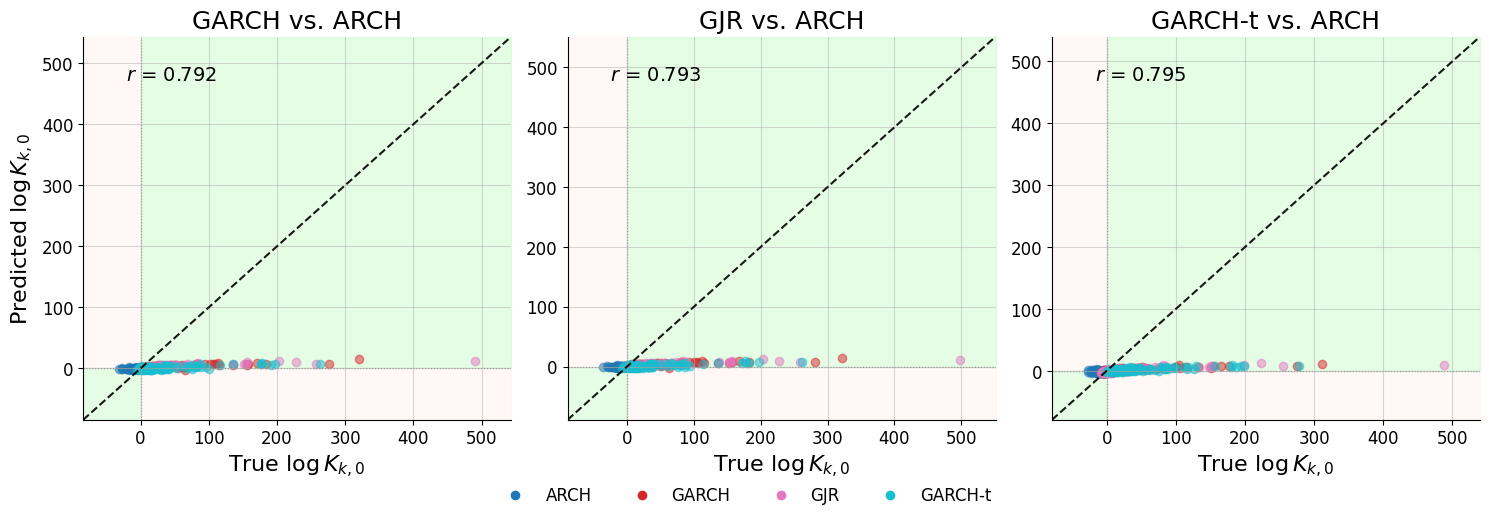

In [24]:
test_data_garch    = bayes_factor_workflow.simulate(500)
pred_log_bfs_garch = bayes_factor_workflow.predict(conditions=test_data_garch)  # (500, 3)

returns_test       = test_data_garch["returns"][:, :, 0]                        # (500, 250)
true_log_bfs_garch = compute_garch_log_bfs(returns_test, S=1000)               # (500, 3); ~40 s

fig = bf_plots.bayes_factor_recovery(
    pred_log_bayes_factors=pred_log_bfs_garch,
    true_log_bayes_factors=true_log_bfs_garch,
    true_models=test_data_garch["model_indices"],
    model_names=MODEL_NAMES,
    reference_model=0,
    add_corr=True,
)
plt.show()